<a href="https://colab.research.google.com/github/sushmasindhu/AI-CODING_LAB-2-/blob/main/HPC_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import time
import random
import multiprocessing
import matplotlib.pyplot as plt

In [4]:
def generate_data(size):
    return [random.randint(1, 1000000) for _ in range(size)]

data = generate_data(1000000)

In [5]:
def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    return result

def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)

In [6]:
def parallel_merge_sort(arr):
    if len(arr) <= 1:
        return arr

    num_processes = multiprocessing.cpu_count()
    pool = multiprocessing.Pool(processes=num_processes)

    size = len(arr) // num_processes
    subarrays = [arr[i:i + size] for i in range(0, len(arr), size)]

    sorted_subarrays = pool.map(merge_sort, subarrays)

    pool.close()
    pool.join()


    while len(sorted_subarrays) > 1:
        new_level = []
        for i in range(0, len(sorted_subarrays), 2):
            if i + 1 < len(sorted_subarrays):
                new_level.append(merge(sorted_subarrays[i], sorted_subarrays[i+1]))
            else:
                new_level.append(sorted_subarrays[i])
        sorted_subarrays = new_level

    return sorted_subarrays[0]

In [7]:
def quick_sort(arr):
    if len(arr) <= 1:
        return arr

    pivot = arr[len(arr)//2]
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]

    return quick_sort(left) + middle + quick_sort(right)

In [8]:
def parallel_quick_sort(arr):
    if len(arr) <= 1:
        return arr

    pivot = arr[len(arr)//2]
    left = [x for x in arr if x < pivot]
    right = [x for x in arr if x > pivot]
    middle = [x for x in arr if x == pivot]

    with multiprocessing.Pool(2) as pool:
        left_sorted, right_sorted = pool.map(quick_sort, [left, right])

    return left_sorted + middle + right_sorted

In [9]:
def measure_time(func, data):
    start = time.time()
    func(data.copy())
    end = time.time()
    return end - start

sizes = [10000, 50000, 100000, 200000]

seq_times = []
par_times = []

for size in sizes:
    data = generate_data(size)

    seq = measure_time(merge_sort, data)
    par = measure_time(parallel_merge_sort, data)

    seq_times.append(seq)
    par_times.append(par)

    print(f"Size: {size}, Sequential: {seq:.4f}, Parallel: {par:.4f}")

Size: 10000, Sequential: 0.0262, Parallel: 0.0612
Size: 50000, Sequential: 0.1449, Parallel: 0.1731
Size: 100000, Sequential: 0.3096, Parallel: 0.3545
Size: 200000, Sequential: 0.6681, Parallel: 0.7165


In [10]:
speedup = [s/p for s, p in zip(seq_times, par_times)]

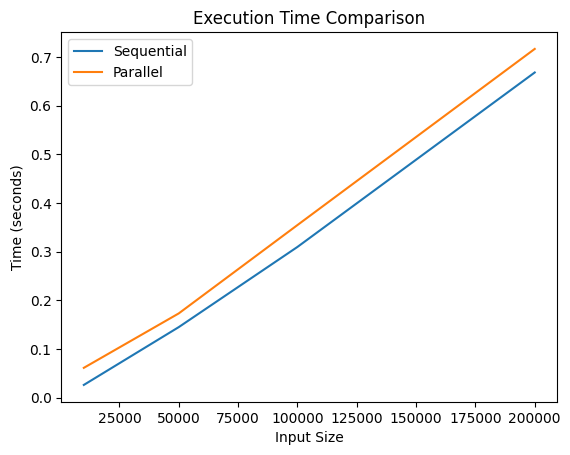

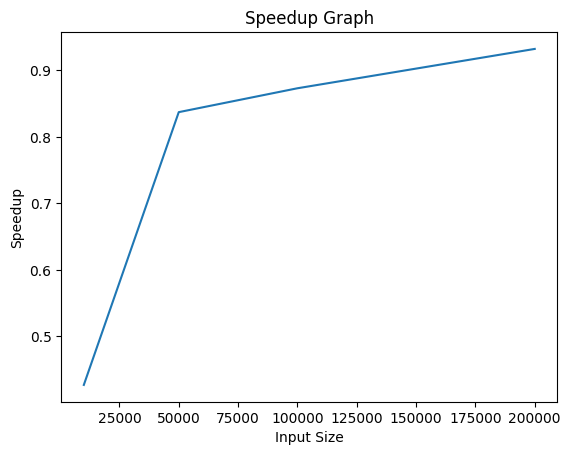

In [11]:
plt.figure()
plt.plot(sizes, seq_times, label="Sequential")
plt.plot(sizes, par_times, label="Parallel")
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Execution Time Comparison")
plt.legend()
plt.show()

plt.figure()
plt.plot(sizes, speedup)
plt.xlabel("Input Size")
plt.ylabel("Speedup")
plt.title("Speedup Graph")
plt.show()

In [12]:
num_cores = multiprocessing.cpu_count()
efficiency = [s/num_cores for s in speedup]

print("Efficiency:", efficiency)

Efficiency: [0.21348937876375584, 0.4186689644531874, 0.43662876829044406, 0.466227042525175]


In [14]:
sizes = [10000, 50000, 100000, 200000]

merge_seq, merge_par = [], []
quick_seq, quick_par = [], []

for size in sizes:
    data = generate_data(size)

    merge_seq.append(measure_time(merge_sort, data))
    merge_par.append(measure_time(parallel_merge_sort, data))

    quick_seq.append(measure_time(quick_sort, data))
    quick_par.append(measure_time(parallel_quick_sort, data))

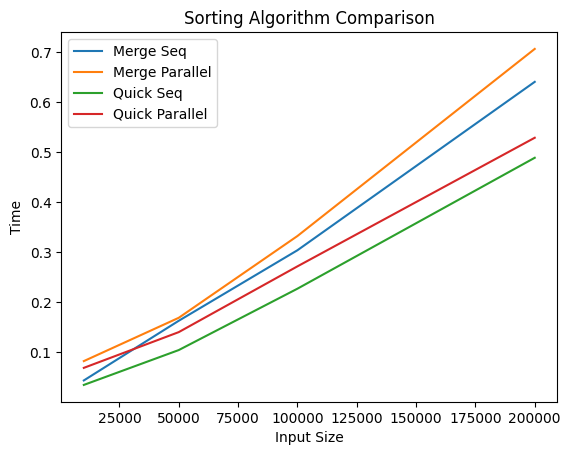

In [15]:
plt.figure()
plt.plot(sizes, merge_seq, label="Merge Seq")
plt.plot(sizes, merge_par, label="Merge Parallel")
plt.plot(sizes, quick_seq, label="Quick Seq")
plt.plot(sizes, quick_par, label="Quick Parallel")
plt.xlabel("Input Size")
plt.ylabel("Time")
plt.title("Sorting Algorithm Comparison")
plt.legend()
plt.show()

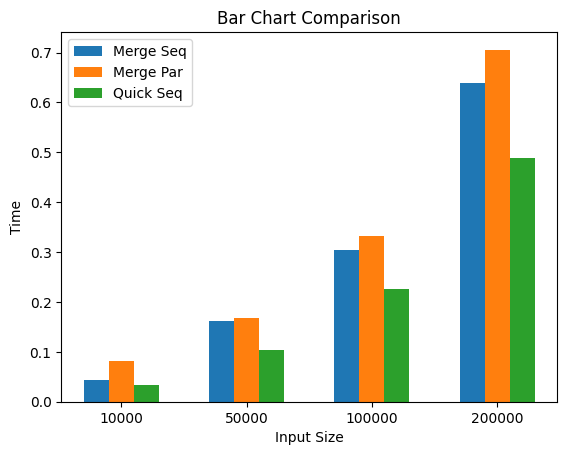

In [16]:
import numpy as np

x = np.arange(len(sizes))

plt.figure()
plt.bar(x - 0.2, merge_seq, 0.2, label="Merge Seq")
plt.bar(x, merge_par, 0.2, label="Merge Par")
plt.bar(x + 0.2, quick_seq, 0.2, label="Quick Seq")

plt.xticks(x, sizes)
plt.xlabel("Input Size")
plt.ylabel("Time")
plt.title("Bar Chart Comparison")
plt.legend()
plt.show()

In [17]:
def parallel_merge_sort_with_cores(arr, cores):
    if len(arr) <= 1:
        return arr

    pool = multiprocessing.Pool(processes=cores)

    size = len(arr) // cores
    subarrays = [arr[i:i + size] for i in range(0, len(arr), size)]

    sorted_subarrays = pool.map(merge_sort, subarrays)

    pool.close()
    pool.join()

    while len(sorted_subarrays) > 1:
        new_level = []
        for i in range(0, len(sorted_subarrays), 2):
            if i + 1 < len(sorted_subarrays):
                new_level.append(merge(sorted_subarrays[i], sorted_subarrays[i+1]))
            else:
                new_level.append(sorted_subarrays[i])
        sorted_subarrays = new_level

    return sorted_subarrays[0]

In [18]:
cores_list = [1, 2, 4, 8]
times = []

data = generate_data(200000)

for c in cores_list:
    start = time.time()
    parallel_merge_sort_with_cores(data, c)
    times.append(time.time() - start)

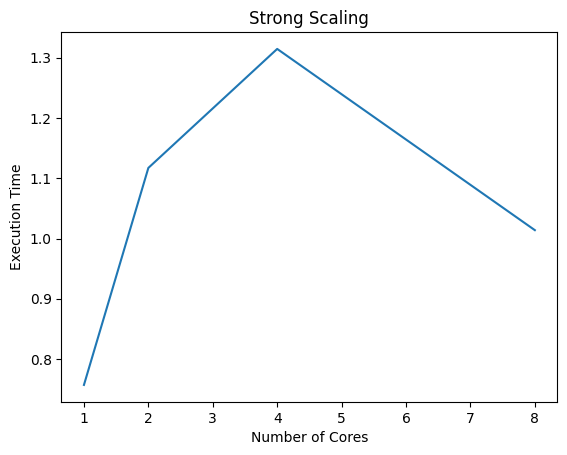

In [19]:
plt.figure()
plt.plot(cores_list, times)
plt.xlabel("Number of Cores")
plt.ylabel("Execution Time")
plt.title("Strong Scaling")
plt.show()

In [20]:
cores_list = [1, 2, 4, 8]
times = []

for c in cores_list:
    data = generate_data(50000 * c)

    start = time.time()
    parallel_merge_sort_with_cores(data, c)
    times.append(time.time() - start)

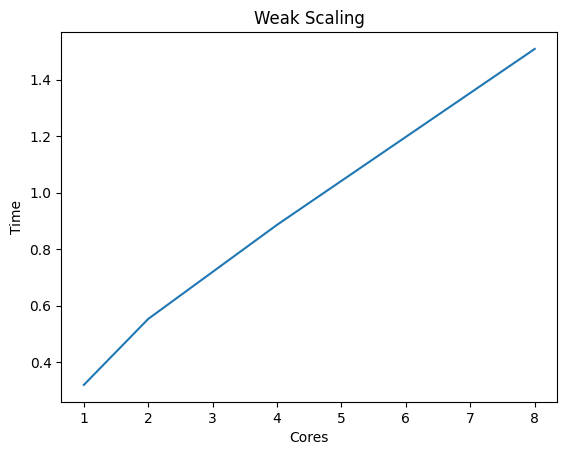

In [21]:
plt.figure()
plt.plot(cores_list, times)
plt.xlabel("Cores")
plt.ylabel("Time")
plt.title("Weak Scaling")
plt.show()

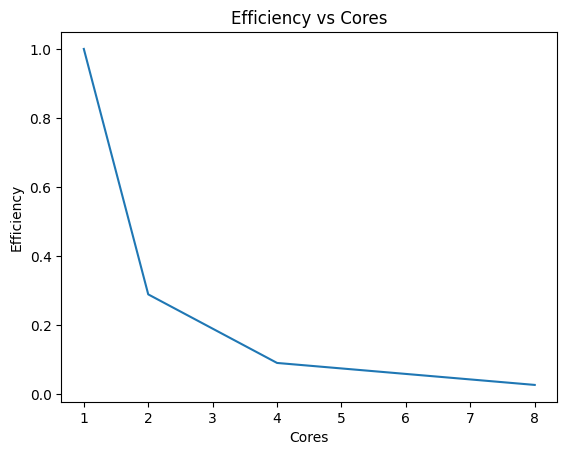

In [22]:
speedup = [times[0]/t for t in times]
efficiency = [s/c for s, c in zip(speedup, cores_list)]

plt.figure()
plt.plot(cores_list, efficiency)
plt.xlabel("Cores")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Cores")
plt.show()

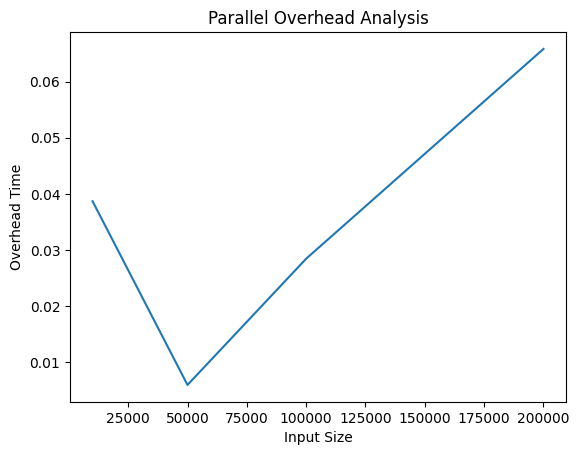

In [23]:
overhead = [par - seq for par, seq in zip(merge_par, merge_seq)]

plt.figure()
plt.plot(sizes, overhead)
plt.xlabel("Input Size")
plt.ylabel("Overhead Time")
plt.title("Parallel Overhead Analysis")
plt.show()

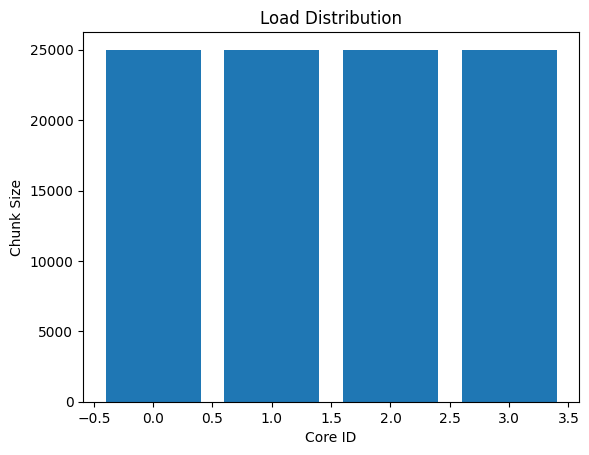

In [24]:
def visualize_chunks(data, cores):
    size = len(data) // cores
    chunks = [len(data[i:i+size]) for i in range(0, len(data), size)]
    return chunks

chunks = visualize_chunks(generate_data(100000), 4)

plt.figure()
plt.bar(range(len(chunks)), chunks)
plt.xlabel("Core ID")
plt.ylabel("Chunk Size")
plt.title("Load Distribution")
plt.show()

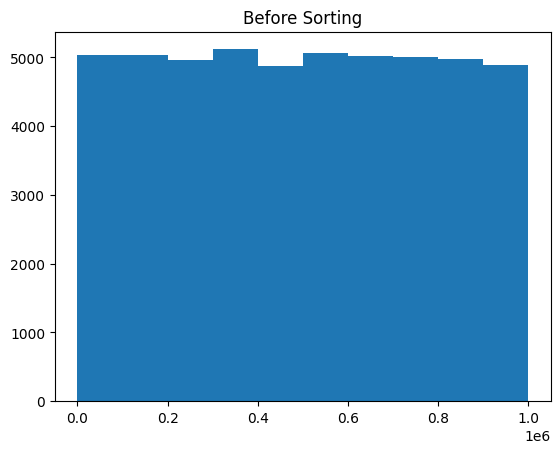

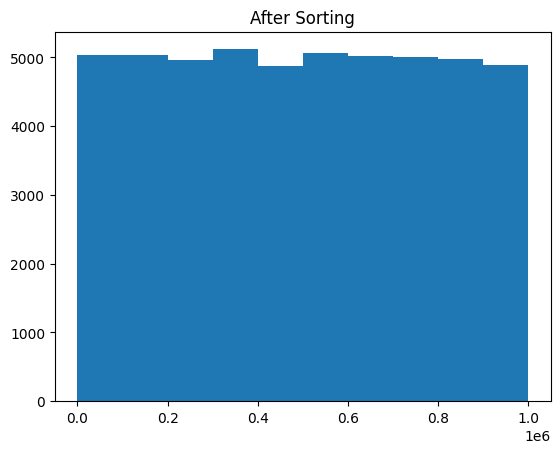

In [25]:
data = generate_data(50000)
sorted_data = merge_sort(data)

plt.figure()
plt.hist(data)
plt.title("Before Sorting")
plt.show()

plt.figure()
plt.hist(sorted_data)
plt.title("After Sorting")
plt.show()

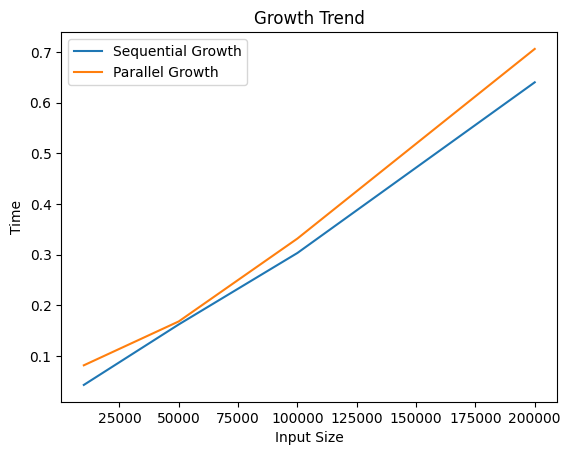

In [26]:
plt.figure()
plt.plot(sizes, merge_seq, label="Sequential Growth")
plt.plot(sizes, merge_par, label="Parallel Growth")
plt.xlabel("Input Size")
plt.ylabel("Time")
plt.title("Growth Trend")
plt.legend()
plt.show()